In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("data\\house-prices.csv")
df.head()

,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,114300,1790.0,2.0,2.0,2.0,No,East
1,114200,2030.0,4.0,2.0,3.0,No,East
2,114800,1740.0,3.0,2.0,1.0,No,East
3,94700,1980.0,3.0,2.0,3.0,No,East
4,119800,2130.0,3.0,3.0,3.0,No,East


## (پیش پردازش)

الان که دیتاست آپلود شد باید پیش پردازش کنیم

یعنی دیتاست را برای train تمیز کنیم

In [5]:
print("="*50)
print("INFO DATAFRAME")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("DESCRIBE (آمار توصیفی)")
print("="*50)
print(df.describe(include='all'))

print("\n" + "="*50)
print("تعداد مقادیر NULL در هر ستون")
print("="*50)
print(df.isna().sum())

INFO DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         128 non-null    int64  
 1   SqFt          126 non-null    float64
 2   Bedrooms      125 non-null    float64
 3   Bathrooms     127 non-null    float64
 4   Offers        126 non-null    float64
 5   Brick         128 non-null    object 
 6   Neighborhood  128 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 7.1+ KB
None

DESCRIBE (آمار توصیفی)
                Price         SqFt    Bedrooms   Bathrooms      Offers Brick  \
count      128.000000   126.000000  125.000000  127.000000  126.000000   128   
unique            NaN          NaN         NaN         NaN         NaN     2   
top               NaN          NaN         NaN         NaN         NaN    No   
freq              NaN          NaN         NaN         NaN         NaN    86   
mea

تابع info:

با استفاده از این تابع جزییات کامل دیتاست را اعم از تایپ و تعداد مقادیر غیر خالی هر ویژگی
######
تابع describe:

این تابع جزییات کامل آمار توصیفی اعم از میانه و میانگین و واریانس و چارک های داده های عددی و فراوانی و داده های غیر عددی
######
تابع isna:

این تابع تعداد سلول های خالی هر ویژگی را نمایش میدهد

با استفاده از عدد واریانس میتوان دید که آیا دیتا ست ما داده های پرت زیادی دارد یا نه

اگر واریانس به 0 نزدیک باشد میتوانیم بگوییم که داده پرت زیادی ندارد
###### ----------------------------------------
برای پر کردن سلول های خالی بهتر

برای ویژگی های پیوسته به واریانس نگاه میکنیم اگر واریانس زیاد باشد بهتر است از میانه استفاده کنیم

اما اگر واریانس نزدیک به صفر باشد از میانگین استفاده میکنیم

اما به طور قطع نمیتوان با واریانس فراوانی داده های پرت را حساب کرد

پس از  IQR برای احتساب این مقادیر استفاده میکنیم

برای داده های پیوسته ویانگین و واریانس معنایی ندارد

برای این ویژگی ها یا از مد استفاده میکنیم یا از میانه

بهتر هست که از میانه استفاده کنیم
###### ----------------------------------------
برای داده پر کردن سلول های غیر عددی

تنها راه حل استفاده از مد یا همان فراوانی هست که کم ریسک ترین راه حل هست

In [6]:
X = df[['SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Brick', 'Neighborhood']]
y = df['Price']
X.head()

,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1790.0,2.0,2.0,2.0,No,East
1,2030.0,4.0,2.0,3.0,No,East
2,1740.0,3.0,2.0,1.0,No,East
3,1980.0,3.0,2.0,3.0,No,East
4,2130.0,3.0,3.0,3.0,No,East


In [7]:
col = "SqFt"

Q1 = X[col].quantile(0.25)
Q3 = X[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
print(f"\n{col}: {len(outliers)} داده پرت")



SqFt: 3 داده پرت


داده هایی که بیشتر از Q3 + 1.5 * IQR باشند

یا کمتر از Q1 - 1.5 * IQR باشند

داده های پرت محسوب میشوند

اما برای داده های پیوسته حساب میکنیم

چون برای پر کردن سلول های خالی ویژگی های گسسته از میانه استفاده میکنیم.

به دلیل وجود داده های پرت بهتر است برای ویژگی های پیوسته هم از میانه استفاده کنیم

In [8]:
numeric_cols = ['SqFt', 'Bedrooms', 'Bathrooms', 'Offers']

for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(df.isna().sum())

Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64


پس تمام سلول های خالی را با میانه پر کردیم

## (مصور سازی)

In [9]:
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

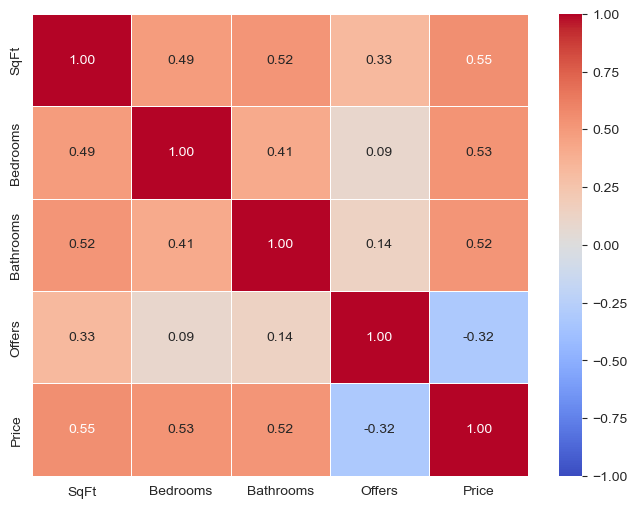

In [10]:
numeric_cols = ['SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Price']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.show()

با این ماتریس همبستگی فهمیدیم که متراژ با قیمت همبستگی خوبی دارد که تغریبا متوسط هست

و همینطور اتاق خواب و دستشویی هم با قیمت خانه همبستگی خوب و متوسطی دارد

پس برای ترین کردن مدل از این مدل های استفاده میکنیم

اما افر که افراد پیشنهادی این خانه هست چون همبستگی منفی دارد از این ویژگی استفاده نمیکنیم

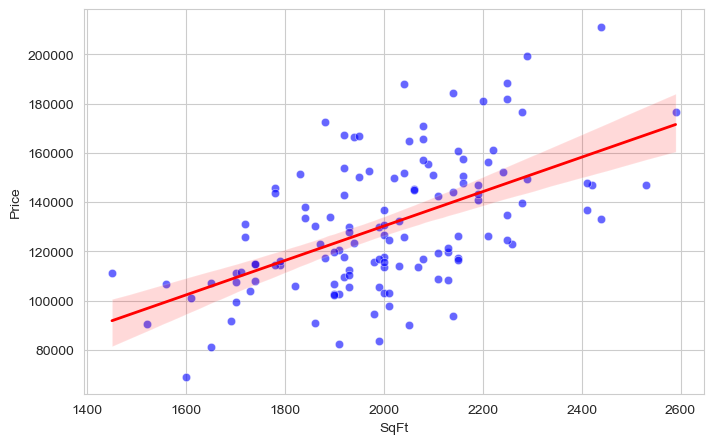

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['SqFt'], y=df['Price'], alpha=0.6, color='blue')
sns.regplot(x=df['SqFt'], y=df['Price'], scatter=False, color='red', line_kws={'linewidth':2})
plt.xlabel('SqFt')
plt.ylabel('Price')
plt.show()

با این نمودار scatterplot و regplot میفهمیم که تقریبا رابطه قیمت و متراژ خطی با شیب مثبت هست

البته داده های پرتی هم واضحا دیده میشور

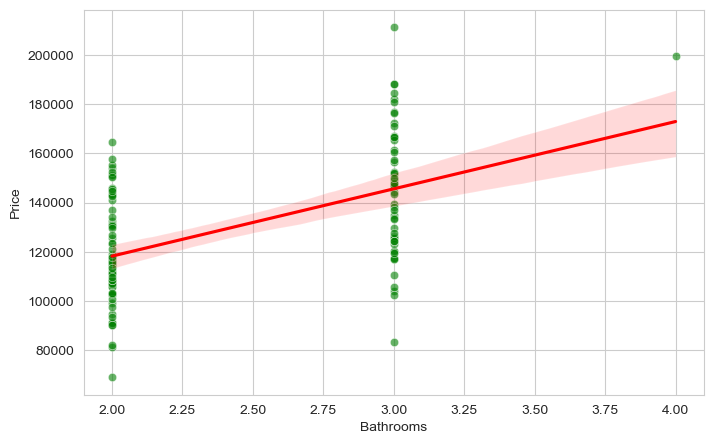

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Bathrooms'], y=df['Price'], alpha=0.6, color='green')
sns.regplot(x=df['Bathrooms'], y=df['Price'], scatter=False, color='red')
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.show()

با این نمودار میفهمیم که رابطه تعداد دستشویی با قیمت خانه مثبت هست اما خطی نیست

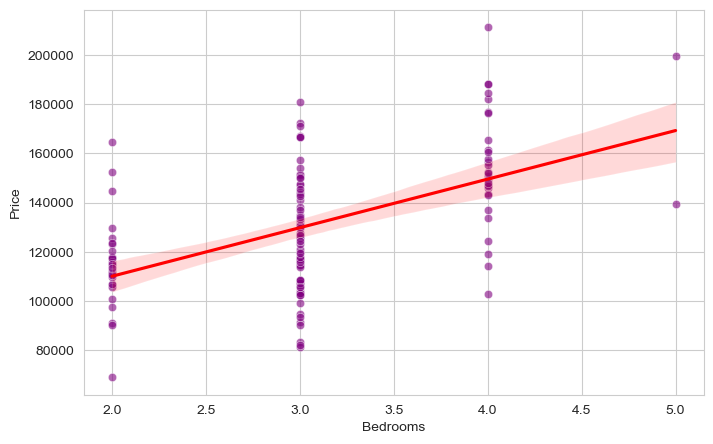

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Bedrooms'], y=df['Price'], alpha=0.6, color='purple')
sns.regplot(x=df['Bedrooms'], y=df['Price'], scatter=False, color='red')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

با این نمودار میفهمیم که رابطه تعداد اتاق خواب با قیمت خانه ضعیف هست

خانه‌های با ۳ اتاق خواب بیشترین تنوع قیمتی را دارند



C:\Users\DELL\AppData\Local\Temp\ipykernel_31004\3260647688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Brick'], y=df['Price'], palette='Set2')


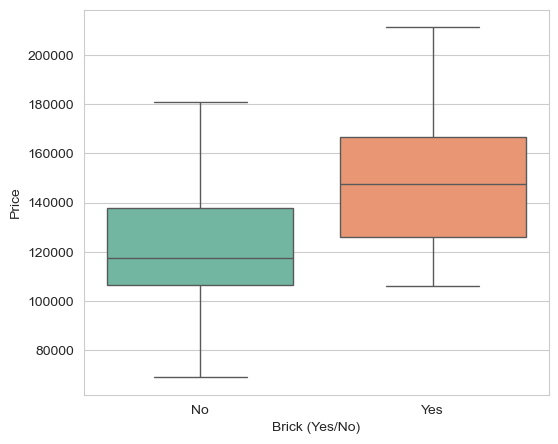

In [14]:
plt.figure(figsize=(6, 5))
sns.boxplot(x=df['Brick'], y=df['Price'], palette='Set2')
plt.xlabel('Brick (Yes/No)')
plt.ylabel('Price')
plt.show()

با این نمودار فهمیدیم خانه‌هایی که آجری هستند میانگین قیمت بالاتری دارند.

میانه قیمت برای Yes به بالاتر از No است.

این ویژگی تأثیر نسبتاً قوی دارد.



C:\Users\DELL\AppData\Local\Temp\ipykernel_31004\1610734980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Neighborhood'], y=df['Price'], order=['East', 'West', 'North'], palette='viridis')


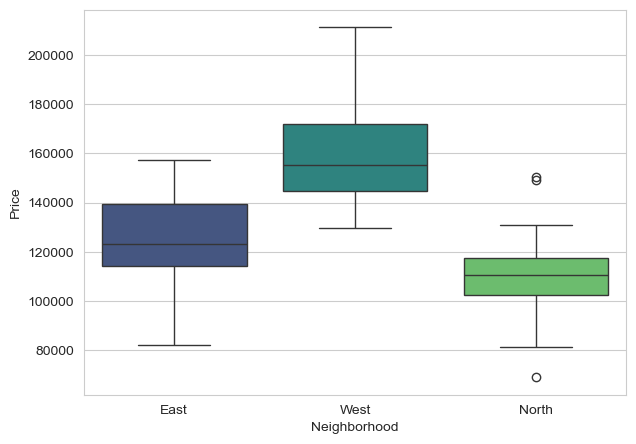

In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=df['Neighborhood'], y=df['Price'], order=['East', 'West', 'North'], palette='viridis')
plt.xlabel('Neighborhood')
plt.ylabel('Price')
plt.show()

با این نمودار فهمیدی که محله های مختلف تاثیر زیادی در فیمت خانه دارد

پس این ویژگی تاثیر قوی دارد.

در نهایت میتوان گفت آن ویژگی هایی که تاثیر مثبت و قوی دارند را برای ترین این مدل استفاده میکنیم

 پیشنهادات که همبستگی منفی داشت در این مدل استفاده نکنیم

## (آماده‌سازی داده و نرمال‌سازی)

In [16]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=['Brick', 'Neighborhood'], drop_first=True)

X = df.drop('Price', axis=1).values
y = df['Price'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [17]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

ابتدا مقادیر غیر عددی را با استفاده از تابع get_dummies عددی میکنیم

حال برای نرمالایز کردن دیتای ورودی

از کلاس  StandardScaler مینویسیم که متد هایش یکی fit هست که واریانس و میانگین را حساب میکند

و متد بعدی transform هست که داده هارا با استفاده از میانگین و انحراف معیار استاندارد میکنه یعنی از هر مقدار میانگین را کم میکنه و تقسیم بر انحراف معیار میکنه

و متد اخر یعنی  fit_transform هر دو کار را با هم انجام میدهد

داده های train را fit_transform میکنیم ولی داده های test را فقط  transform میکنیم

برای اینکه اگر داده های test را هم fit کنیم باعث نشت اطلاعات میشود و دیگر ارزیابی مدل درست در نمی آید

In [18]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        X_bias = self._add_bias(np.asarray(X, dtype=np.float64))
        y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
        n_samples = X_bias.shape[0]
        self.weights = np.zeros((X_bias.shape[1], 1))

        for i in range(self.n_iter):
            y_pred = X_bias @ self.weights
            error = y_pred - y
            gradients = (1/n_samples) * (X_bias.T @ error)
            self.weights -= self.lr * gradients
            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        X_bias = self._add_bias(np.asarray(X, dtype=np.float64))
        return X_bias @ self.weights

    def score(self, X, y):
        y_pred = self.predict(X)
        y = np.asarray(y).reshape(-1, 1)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

کلاس LinearRegressionGD رگرسیون خطی را با روش گرادیان کاهشی از ابتدا پیاده‌سازی کردیم

اول بایاس به ماتریس ویژگی اضافه میشود

و متد fit وزن‌ها را با محاسبه گرادیان خطا بر اساس داده های train تنظیم میکنیم و با یک حلقه در هر تکرار بروزرسانی میکنیم

و متد predict با ضرب ماتریس ویژگی‌ها که با بایاس حساب شده بود در وزن‌هایی که در متد fit تنظیم شده بود مقادیر پیش بینی شده را حساب میکنه

و متد score ضریب تعیین را محاسبه میکنه

In [20]:
model = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)

model.fit(X_train_norm, y_train)

train_score = model.score(X_train_norm, y_train)
test_score = model.score(X_test_norm, y_test)

print(f"R^2 on train: {train_score:.4f}")
print(f"R^2 on test: {test_score:.4f}")

R^2 on train: 0.8582
R^2 on test: 0.8858


اینجا مدل رگرسیون خطی را با نرخ یادگیری ۰٫۰۱ و ۱۰۰۰ تکرار می‌سازد، روی داده‌های train نرمال‌شده train میکند و بعد R² (ضریب تعیین) را برای هر دو داده train و test حساب میکنه.

خروجی نشان می‌دهد مدل حدود ۸۶٪ و ۸۹٪ از تغییرات قیمت را به ترتیب در train و test توضیح می‌دهد که عملکرد بسیار خوبی است.

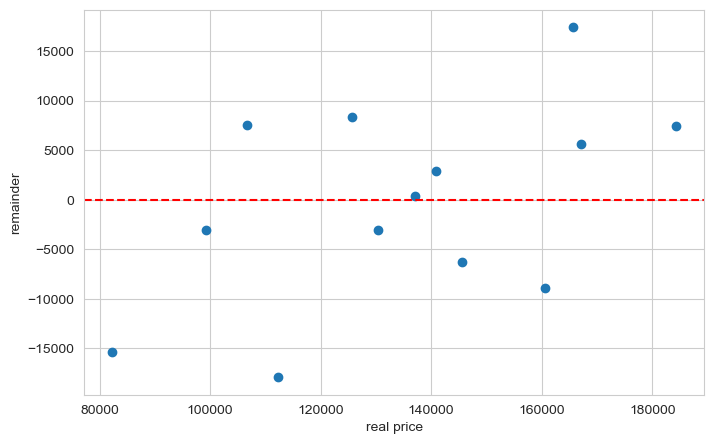

In [22]:
residuals = y_test - model.predict(X_test_norm)
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('real price')
plt.ylabel('remainder')
plt.show()

این نمودار پراکندگی باقیمانده‌ها یعنی همون خطای پیش‌بینی را در برابر قیمت واقعی برای بررسی تصادفی بودن خطاها و عدم وجود الگو (روند، خوشه‌ای یا واریانس ناهمسانی).

خط قرمز صفر نشان‌دهنده خطای صفر است.


# (تابع هدف)

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train_rmse = rmse(y_train, model.predict(X_train_norm))
test_rmse = rmse(y_test, model.predict(X_test_norm))
print(f"RMSE on train: {train_rmse:.2f}")
print(f"RMSE on test: {test_rmse:.2f}")

RMSE on train: 9973.15
RMSE on test: 9689.08


این کد تابع rmse جذر میانگین مربعات اختلاف بین قیمت واقعی و پیش‌بینی را محاسبه می‌کنه
این خروجی یعنی مدل میانگین خطای پیش‌بینی قیمت را حدود ۹۷۰۰ تا ۹۹۰۰ دلار دارد و خطای test کمی کمتر از train است و این یعنی عملکرد مدل خوب بوده.

# (تمام)